# Coffee Shop A/B Test: From Simulation to Statistical Inference

**A hands-on course in building, analyzing, and interpreting experiments**

---

## Before You Begin

### Learning Objectives

By the end of this lesson, you will be able to:

1. **Build** a data simulator using object-oriented programming
2. **Manipulate and explore** data using pandas (Series, DataFrames, filtering, groupby)
3. **Interpret** the results of a two-sample t-test
4. **Explain** the difference between statistical significance and practical importance
5. **Calculate** statistical power and explain why sample size matters

### Prerequisites

- Basic Python: variables, functions, loops, dictionaries
- No prior experience with statistics, OOP, or pandas required

### Why This Matters

A/B testing is how modern companies make data-driven decisions. But here's the catch: **you can run an A/B test and still draw the wrong conclusion**. This lesson builds the foundation for thinking critically about experiments.

---

## The Big Picture

We'll work through **five connected lessons** in sequence:

| Lesson | Question | Tool | Output |
|--------|----------|------|--------|
| 0 | What math concepts do I need? | Fundamentals | Understand normal distribution and standard error |
| 1 | How do I generate realistic data? | OOP classes | A data simulator |
| 2 | How do I work with and explore data? | Pandas | Learn Series, DataFrames, filtering, groupby |
| 3 | Is the difference real or noise? | Hypothesis testing | p-values, confidence intervals |
| 4 | How confident should I be? | Power analysis | Sample size recommendations |

Each lesson builds on the previous one. The flow is: **Understand → Build → Explore → Test → Interpret**.

---

# Setup: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Set random seed for reproducibility
# this will generate psuedo RNG 
np.random.seed(42)

---

# Part 0: Math Foundations

This section covers the key statistical concepts you'll need. **Don't memorize formulas** — we implement everything in Python. The goal is understanding what the math means.

## The Normal Distribution (Gaussian Distribution)

### What It Is

The **normal distribution** is the classic bell curve. It's fundamental to statistics because of a remarkable fact:

> **Central Limit Theorem:** If you average many observations, the average follows a normal distribution — even if the individual observations don't!

This is why we use normal/t-distributions for hypothesis testing. We're testing **averages**, not individual values.

### Key Facts

A normal distribution is completely described by two parameters:
- **μ (mu)**: The mean — where the curve is centered
- **σ (sigma)**: The standard deviation — how spread out the curve is

Written as: X ~ N(μ, σ)

### The 68-95-99.7 Rule

For any normal distribution:
- **68%** of data falls within 1 std dev of the mean (μ ± σ)
- **95%** falls within 2 std devs (μ ± 2σ)
- **99.7%** falls within 3 std devs (μ ± 3σ)

In [2]:
# The Normal Distribution: Worked Example

mu = 35  # Mean age in years
sigma = 10  # Standard deviation

print("=" * 70)
print("Normal Distribution Example: Customer Age")
print("=" * 70)
print(f"\nScenario: Customer age ~ N({mu}, {sigma})")
print(f"\nThe 68-95-99.7 Rule:")
print(f"  68% of customers are {mu-sigma}-{mu+sigma} years old (25-45)")
print(f"  95% of customers are {mu-2*sigma}-{mu+2*sigma} years old (15-55)")
print(f"  99.7% of customers are {mu-3*sigma}-{mu+3*sigma} years old (5-65)")

# Calculate specific probabilities
print(f"\nSpecific Probabilities (using scipy.stats):")
prob_25_45 = stats.norm.cdf(45, mu, sigma) - stats.norm.cdf(25, mu, sigma)
print(f"  P(25 < age < 45) = {prob_25_45:.4f} = {prob_25_45*100:.1f}%")

prob_over_55 = 1 - stats.norm.cdf(55, mu, sigma)
print(f"  P(age > 55) = {prob_over_55:.4f} = {prob_over_55*100:.2f}%")

# Simulate data from normal distribution
print(f"\nVerification (simulate 10,000 ages):")
ages = np.random.normal(mu, sigma, 10000)
print(f"  Simulated mean: {ages.mean():.1f} (expected {mu})")
print(f"  Simulated std: {ages.std():.1f} (expected {sigma})")
print(f"  Simulated % in 25-45 range: {((ages >= 25) & (ages <= 45)).sum() / len(ages) * 100:.1f}% (expected 68%)")
print(f"  Simulated % over 55: {(ages > 55).sum() / len(ages) * 100:.2f}% (expected 2.5%)")
print("=" * 70)

Normal Distribution Example: Customer Age

Scenario: Customer age ~ N(35, 10)

The 68-95-99.7 Rule:
  68% of customers are 25-45 years old (25-45)
  95% of customers are 15-55 years old (15-55)
  99.7% of customers are 5-65 years old (5-65)

Specific Probabilities (using scipy.stats):
  P(25 < age < 45) = 0.6827 = 68.3%
  P(age > 55) = 0.0228 = 2.28%

Verification (simulate 10,000 ages):
  Simulated mean: 35.0 (expected 35)
  Simulated std: 10.0 (expected 10)
  Simulated % in 25-45 range: 68.2% (expected 68%)
  Simulated % over 55: 2.37% (expected 2.5%)


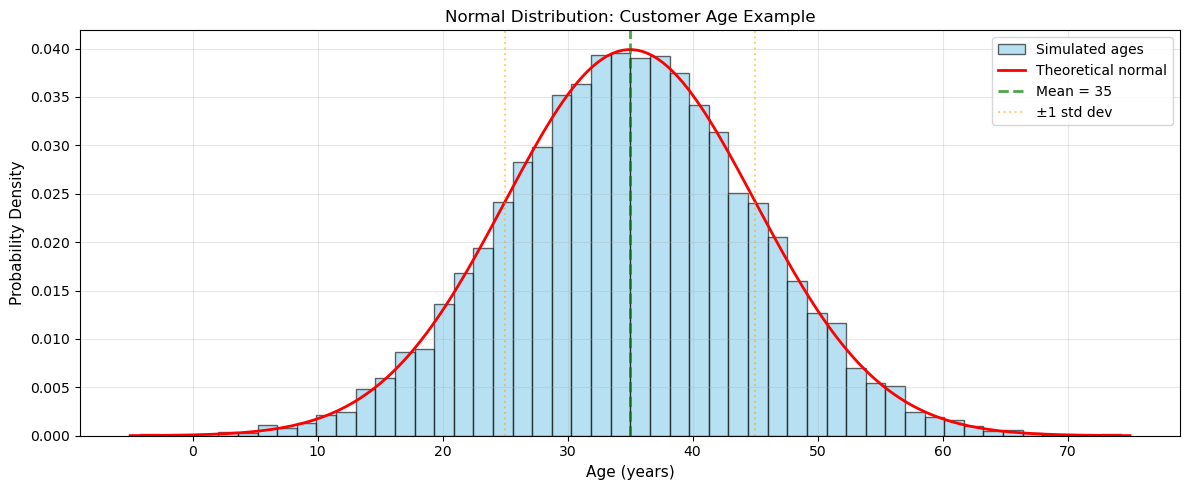

In [3]:
# Visualize the normal distribution
fig, ax = plt.subplots(figsize=(12, 5))

# Histogram of simulated data
ax.hist(ages, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Simulated ages')

# Theoretical normal curve
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
y = stats.norm.pdf(x, mu, sigma)
ax.plot(x, y, 'r-', linewidth=2, label='Theoretical normal')

# Mark standard deviations
ax.axvline(mu, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Mean = {mu}')
ax.axvline(mu - sigma, color='orange', linestyle=':', linewidth=1.5, alpha=0.5)
ax.axvline(mu + sigma, color='orange', linestyle=':', linewidth=1.5, alpha=0.5, label=f'±1 std dev')

ax.set_xlabel('Age (years)', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title('Normal Distribution: Customer Age Example', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Standard Deviation and Standard Error

### What's the Difference?

These are two different concepts that are often confused:

**Standard Deviation (σ):** How spread out individual values are from the mean.
- Formula: σ = √(average squared deviation from mean)
- Use: Describing variability in your data
- Example: Service times vary by ~2.5 minutes

**Standard Error (SE):** How much your **sample average** bounces around.
- Formula: SE = σ / √n
- Use: Building confidence intervals, hypothesis testing
- Example: With n=100 samples, our estimate has uncertainty of ±0.25 minutes

### Why Standard Error Matters

With more data, your average estimate becomes **more precise** (smaller SE), even though individual values still vary (same σ).

### Worked Example

In [ ]:
# Standard Deviation vs Standard Error

# Small sample of service times (in minutes)
service_times = np.array([2.1, 1.9, 2.8, 2.3, 2.2, 1.8, 2.5, 2.1, 2.4, 2.0])
mean = service_times.mean()
std_dev = service_times.std(ddof=1)  # Sample std dev # we do ddof as it degrees of freedom lost (it is like n-1 for this example)
n = len(service_times)
std_error = std_dev / np.sqrt(n)

print("=" * 70)
print("Standard Deviation vs Standard Error")
print("=" * 70)
print(f"\nData: {n} barista service times (in minutes)")
print(f"  {service_times}")

print(f"\nMean: {mean:.2f} minutes")

print(f"\nStandard Deviation: {std_dev:.3f} minutes")
print(f"  → Individual times vary by ~{std_dev:.2f} minutes")
print(f"  → This is the variability we observe in the data")

print(f"\nStandard Error: {std_error:.3f} minutes")
print(f"  → Our average estimate ({mean:.2f}) has precision of ±{std_error:.2f} minutes")
print(f"  → 95% Confidence Interval: [{mean - 1.96*std_error:.2f}, {mean + 1.96*std_error:.2f}]")

print(f"\nWhat if we had 100 times as much data?")
n_large = n * 100
se_large = std_dev / np.sqrt(n_large)
print(f"  SE = {std_dev:.3f} / √{n_large} = {se_large:.4f} minutes")
print(f"  Much more precise!")
print(f"  This is why bigger samples matter.")
print("=" * 70)

## The t-Distribution

The **t-distribution** is similar to the normal distribution but with **heavier tails** — more extreme values are possible. It's used when:
1. Your sample size is small
2. You estimate the standard deviation from your data (don't know the true population σ)

Key feature: The t-distribution approaches the normal distribution as your sample size increases. With n > 30, they're essentially the same.

**Degrees of freedom (df):** Controls how heavy the tails are. For a two-sample t-test with groups of size n₁ and n₂, df ≈ n₁ + n₂ − 2. Higher df → thinner tails → closer to normal. The plots below show df=5 (very small samples) and df=30 (moderate samples).

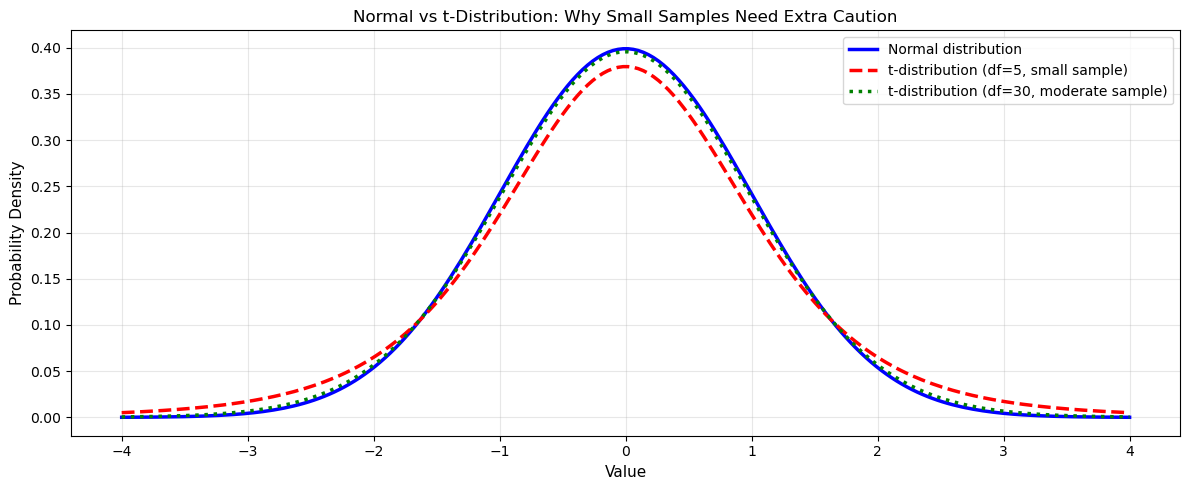

Key observation: With df=5 (small sample), the t-distribution has
heavier tails than normal. With df=30+, they're essentially the same.


In [ ]:
# Compare normal and t-distributions
x = np.linspace(-4, 4, 200)
# curtosis 

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, stats.norm.pdf(x), 'b-', linewidth=2.5, label='Normal distribution')
ax.plot(x, stats.t.pdf(x, df=5), 'r--', linewidth=2.5, label='t-distribution (df=5, small sample)')
ax.plot(x, stats.t.pdf(x, df=30), 'g:', linewidth=2.5, label='t-distribution (df=30, moderate sample)')

ax.set_xlabel('Value', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title('Normal vs t-Distribution: Why Small Samples Need Extra Caution', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Key observation: With df=5 (small sample), the t-distribution has")
print("heavier tails than normal. With df=30+, they're essentially the same.")

## Why Exponential Distribution for Service Times?

In our coffee shop simulator, we'll generate service times from an **exponential distribution**. Here's why:

**Characteristics:**
- Most customers are served quickly (left side)
- Occasional customers take much longer (right tail)
- Models the time between random events

**Why it matches reality:**
- Most orders are simple (coffee to go)
- Occasionally complex orders (custom drink with modifications)
- Waiting time doesn't depend on how long you've already waited (memoryless)

We'll generate service times with: `np.random.exponential(mean)`. That's all you need to know for now.

---

# Part 1: Building a Simulator with OOP

## The Question

> *How do we generate realistic data that looks like a real coffee shop?*

## Why This Matters

Real data is expensive and slow to collect. **Simulation** lets us generate unlimited data instantly — and we know the ground truth because we built it.

## Learning Goals

- Use **classes** to organize related data and behavior
- See **polymorphism**: same interface, different implementations
- Generate data that we can analyze with pandas

### The Core Idea: Classes as Data Generators

A coffee shop has different types of employees:
- **Fast baristas**: quick service (~2.5 min), more mistakes (~15% error)
- **Careful baristas**: slower service (~4.0 min), fewer mistakes (~2% error)

We'll model this with classes:
- A base `Barista` class defines the interface
- `FastBarista` and `CarefulBarista` implement their specific behavior
- Both share the same methods, but with different logic (**polymorphism**)

In [ ]:
class Barista:
    """Parent class: Defines what ANY barista can do."""
    
    def __init__(self, name):
        self.name = name
    
    def serve_customer(self):
        """Serve one customer. Subclasses must implement this."""
        raise NotImplementedError("Subclasses must implement serve_customer()")
    
    def serve_shift(self, n_customers):
        """Serve many customers. Returns list of order dicts."""
        return [self.serve_customer() for _ in range(n_customers)]
# lst = []
# for value in range(n_customers):
    # lst.append(self.serve_customers)


class FastBarista(Barista):
    """Fast barista: quick service, higher error rate."""
    
    def serve_customer(self):
        service_time = np.random.exponential(2.5)  # Mean: 2.5 minutes
        order_correct = np.random.random() > 0.15  # 15% error rate
        return {
            "barista_type": "Fast",
            "service_time": service_time,
            "order_correct": order_correct,
        }

class CarefulBarista(Barista):
    """Careful barista: slower service, lower error rate."""
    
    def serve_customer(self):
        service_time = np.random.exponential(4.0)  # Mean: 4.0 minutes
        order_correct = np.random.random() > 0.02  # 2% error rate
        return {
            "barista_type": "Careful",
            "service_time": service_time,
            "order_correct": order_correct,
        }


# Test the classes
alice = FastBarista("Alice")
print("Sample order from Fast barista:")
print(alice.serve_customer())
print("\nFull shift (5 customers):")
for i, order in enumerate(alice.serve_shift(5), 1):
    print(f"  Order {i}: {order['service_time']:.2f} min, Correct: {order['order_correct']}")

Sample order from Fast barista:
{'barista_type': 'Fast', 'service_time': 0.9687750743391359, 'order_correct': False}

Full shift (5 customers):
  Order 1: 0.19 min, Correct: False
  Order 2: 2.19 min, Correct: False
  Order 3: 1.03 min, Correct: True
  Order 4: 0.87 min, Correct: True
  Order 5: 3.42 min, Correct: True


### Exercise 1.1: Build Your Own Barista

Create a `BalancedBarista` with:
- **Average service time**: 3.0 minutes
- **Error rate**: 7%

Test it by serving 5 customers.

In [ ]:
class BalancedBarista(Barista):
    """TODO: Balanced barista — medium speed, medium error rate."""

    def serve_customer(self):
        # TODO: generate service_time using np.random.exponential with mean 3.0
        # TODO: generate order_correct — True 93% of the time (error rate 7%)
        # TODO: return a dict with keys: barista_type, service_time, order_correct
        pass


# Test your implementation (run AFTER completing the TODOs above)
balanced = BalancedBarista("Charlie")
result = balanced.serve_customer()

if result is None:
    print("️⚠  Finish the TODOs above first.")
    print("   serve_customer() must return a dict, not None.")
else: 
    print("Single order:", result)
    print("\nFull shift (5 customers):")
    for i, order in enumerate(balanced.serve_shift(5), 1):
        print(f"  Order {i}: {order['service_time']:.2f} min, Correct: {order['order_correct']}")
# enumerate give the values from a specific index {index:item}

️⚠  Finish the TODOs above first.
   serve_customer() must return a dict, not None.


---

# Part 2: Exploring Data with Pandas

## The Question

> *How do we work with and understand the data we generated?*

## Why This Matters

Pandas is the industry standard for data analysis. We'll learn it in the context of exploring real data — not abstract examples.

## Learning Goals

- Understand **Series** (single column of data)
- Understand **DataFrames** (tables with multiple columns)
- **Index and select** data using different methods
- **Filter** data to ask specific questions
- **Group and aggregate** to compare subgroups
- **Visualize** patterns in the data

## Generate Real Data First

Let's create a dataset from our simulator, then learn pandas by exploring it.

In [ ]:
# ⚠️  This cell requires Exercise 1.1 to be complete.
# Run it only after BalancedBarista.serve_customer() returns a dict.
_check = BalancedBarista("_check").serve_customer()
if _check is None:
    raise RuntimeError(
        "Complete Exercise 1.1 first — BalancedBarista.serve_customer() still returns None.\n"
        "All of Parts 2–4 depend on this cell."
    )
del _check

# Generate realistic data: Each barista type serves 500 customers
fast = FastBarista("Fast")
careful = CarefulBarista("Careful")
balanced = BalancedBarista("Balanced")

# Collect orders
fast_orders = fast.serve_shift(500)
careful_orders = careful.serve_shift(500)
balanced_orders = balanced.serve_shift(500)

# Convert to DataFrame
df = pd.DataFrame(fast_orders + careful_orders + balanced_orders)

print(f"Total orders: {len(df)}")
print(f"Barista types: {df['barista_type'].unique()}")
print(f"\nFirst 5 rows:")
print(df.head())

## Understanding Series

In [ ]:
# Extract a single column
service_times = df['service_time']

print("=" * 70)
print("Understanding Pandas Series")
print("=" * 70)
print(f"\nA Series is a labeled column of data:")
print(f"Type: {type(service_times)}")
print(f"Shape: {service_times.shape}  (1D — single column)")
print(f"\nFirst 5 values:")
print(service_times.head())

print(f"\nCommon Operations:")
print(f"  Mean: {service_times.mean():.2f} minutes")
print(f"  Std dev: {service_times.std():.2f} minutes")
print(f"  Max: {service_times.max():.2f} minutes")
print(f"  Min: {service_times.min():.2f} minutes")

print(f"\nFiltering (service_time > 5):")
filtered = service_times[service_times > 5]
print(f"  Found {len(filtered)} orders taking > 5 minutes")
print(f"  Mean of those slow orders: {filtered.mean():.2f} minutes")
print("=" * 70)

## Understanding DataFrames

In [ ]:
print("=" * 70)
print("Understanding Pandas DataFrames")
print("=" * 70)

print(f"\nA DataFrame is a table (rows × columns):")
print(f"Shape: {df.shape}  ({df.shape[0]} rows, {df.shape[1]} columns)")
print(f"Columns: {list(df.columns)}")

print(f"\nData types:")
print(df.dtypes)

print(f"\nFirst and last rows:")
print(df.head(2))
print("...")
print(df.tail(2))
print("=" * 70)

## Selecting Data

In [ ]:
print("=" * 70)
print("Four Ways to Select Data from a DataFrame")
print("=" * 70)

print("\n1. SELECT A SINGLE COLUMN (returns a Series):")
print("   df['barista_type']")
print(df['barista_type'].head())

print("\n2. SELECT MULTIPLE COLUMNS (returns a DataFrame):")
print("   df[['barista_type', 'service_time']]")
print(df[['barista_type', 'service_time']].head())

print("\n3. SELECT A SINGLE ROW BY INDEX (returns a Series):")
print("   df.loc[0]")
print(df.loc[0])

print("\n4. SELECT MULTIPLE ROWS:")
print("   df.loc[1:3]")
print(df.loc[1:3])

print("\n" + "=" * 70)
print("KEY DISTINCTION:")
print("=" * 70)
print("  df[['column']] → DataFrame (double brackets)")
print("  df['column'] → Series (single brackets)")

## Filtering with Boolean Masks

In [ ]:
print("=" * 70)
print("Filtering: Using Boolean Masks")
print("=" * 70)

print("\n1. SINGLE CONDITION:")
print("   df[df['barista_type'] == 'Fast']")
fast_only = df[df['barista_type'] == 'Fast']
print(f"   Found {len(fast_only)} Fast barista orders")

print("\n2. ANOTHER CONDITION:")
print("   df[df['service_time'] > 5.0]")
slow_orders = df[df['service_time'] > 5.0]
print(f"   Found {len(slow_orders)} orders taking > 5 minutes")

print("\n3. COMBINE WITH AND (&):")
print("   df[(df['barista_type'] == 'Fast') & (df['order_correct'] == True)]")
fast_correct = df[(df['barista_type'] == 'Fast') & (df['order_correct'] == True)]
print(f"   Found {len(fast_correct)} correct Fast barista orders")

print("\n4. COMBINE WITH OR (|):")
print("   df[(df['service_time'] < 1.0) | (df['service_time'] > 8.0)]")
extreme = df[(df['service_time'] < 1.0) | (df['service_time'] > 8.0)]
print(f"   Found {len(extreme)} extreme service times (very fast or very slow)")

print("\n5. NEGATION (~):")
print("   df[~(df['order_correct'] == True)]  # Wrong orders only")
wrong = df[~(df['order_correct'] == True)]
print(f"   Found {len(wrong)} wrong orders out of {len(df)} total")

print("\n" + "=" * 70)
print("⚠️  IMPORTANT:")
print("=" * 70)
print("Use & and | for DataFrames, NOT 'and'/'or'")
print("✓ df[(df['a'] == 1) & (df['b'] == 2)]  # CORRECT")
print("✗ df[(df['a'] == 1) and (df['b'] == 2)]  # WRONG — will crash")

## Groupby: The Split-Apply-Combine Pattern

In [ ]:
print("=" * 70)
print("Groupby: Split-Apply-Combine")
print("=" * 70)

print("\nWorkflow:")
print("  1. SPLIT: Divide data by barista_type")
print("  2. APPLY: Compute something for each group")
print("  3. COMBINE: Merge results back together")

print("\n1. MEAN SERVICE TIME BY BARISTA:")
print("   df.groupby('barista_type')['service_time'].mean()")
print(df.groupby('barista_type')['service_time'].mean().round(2))

print("\n2. MULTIPLE STATISTICS:")
print("   df.groupby('barista_type')['service_time'].agg(['mean', 'std', 'count', 'min', 'max'])")
print(df.groupby('barista_type')['service_time'].agg(['mean', 'std', 'count', 'min', 'max']).round(2))

print("\n3. CORRECTNESS RATE BY BARISTA:")
print("   df.groupby('barista_type')['order_correct'].mean()")
accuracy = df.groupby('barista_type')['order_correct'].mean().round(3)
print(accuracy)
print("\n   (Note: .mean() on True/False gives proportion of True values)")

print("\n4. COUNT PER GROUP:")
print("   df.groupby('barista_type').size()")
print(df.groupby('barista_type').size())
print("=" * 70)

### Exercise 2.1: Practice with Real Data

Using the `df` we generated, answer these:

1. How many Fast barista orders are correct?
2. What's the average service time for Careful baristas only?
3. What proportion of wrong orders came from Fast baristas?

In [ ]:
# 1. How many Fast barista orders are correct?
#    Hint: filter df for Fast baristas AND correct orders, then count rows


# 2. What's the average service time for Careful baristas only?
#    Hint: filter df for Careful, then take .mean() of service_time


# 3. What proportion of wrong orders came from Fast baristas?
#    Hint: first filter to wrong orders, then find what fraction are Fast
#    Note: this is different from the Fast barista error *rate* — think about what the question is asking

## Exploring the Data: Summary and Visualization

In [ ]:
# The First Look Ritual
print("=" * 70)
print("First Look: Shape, Types, and Summary")
print("=" * 70)

print(f"\n1. SHAPE:")
print(f"   {df.shape}  ({df.shape[0]} rows, {df.shape[1]} columns)")

print(f"\n2. DATA TYPES:")
print(df.dtypes)

print(f"\n3. SUMMARY STATISTICS:")
print(df.describe())
print("=" * 70)

In [ ]:
# Compare groups
print("=" * 70)
print("Comparing Barista Types")
print("=" * 70)

print("\nSERVICE TIME STATISTICS:")
time_stats = df.groupby('barista_type')['service_time'].agg(['mean', 'std', 'count']).round(2)
print(time_stats)

print("\nORDER CORRECTNESS:")
correctness = df.groupby('barista_type')['order_correct'].mean().round(3)
error_rates = (1 - correctness).round(3)
comparison = pd.DataFrame({
    'proportion_correct': correctness,
    'error_rate': error_rates
})
print(comparison)

print("\nVerification (matching expectations):")
for btype, expected_error in [('Fast', 0.15), ('Careful', 0.02), ('Balanced', 0.07)]:
    actual = 1 - df[df['barista_type'] == btype]['order_correct'].mean()
    print(f"  {btype}: Expected ~{expected_error*100:.0f}%, Got {actual*100:.1f}%")
print("\n✓ Simulator matches expectations!")
print("=" * 70)

In [ ]:
# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

barista_types = ['Fast', 'Careful', 'Balanced']
colors = ['blue', 'orange', 'green']

for ax, btype, color in zip(axes, barista_types, colors):
    times = df[df['barista_type'] == btype]['service_time']
    ax.hist(times, bins=30, alpha=0.7, color=color, edgecolor='black')
    ax.axvline(times.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={times.mean():.1f}')
    ax.set_xlabel('Service Time (minutes)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'{btype} Barista (n={len(times)})', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Exercise 2.2: Explore Wrong Orders

Among wrong orders only, compare mean service times across barista types. What do you observe?

In [ ]:
# Among wrong orders only, compare mean service times across barista types.
# Step 1: filter df to only wrong orders
wrong_orders = df[df['order_correct'] == False]

# Step 2: use groupby to get mean service time and count for each barista type


# What do you observe? Why might the service times look the way they do?

---

# Part 3: Hypothesis Testing

## The Question

> *Is the difference real, or just random luck?*

## Why This Matters

**Every sample shows some difference.** Hypothesis testing tells us whether the difference is **larger than we'd expect from noise alone**.

## Learning Goals

- State null and alternative hypotheses
- Interpret p-values correctly
- Understand: **statistical significance ≠ practical importance**

> **Connection to Part 0:** The t-statistic formula is t = (x̄₁ − x̄₂) / SE, where SE is exactly the standard error from Part 0: SE = √(σ₁²/n + σ₂²/n). Bigger samples → smaller SE → larger t → smaller p-value. The test is asking: "Is this observed difference large *relative to its expected noise*?"

### The Two Hypotheses

**H₀ (null hypothesis):** No real difference. Any gap we see is just random noise.

**H₁ (alternative hypothesis):** There IS a real difference.

We can't prove H₁. Instead, we ask: *"If H₀ were true, how surprised would we be to see this data?"*

That's the p-value.

In [ ]:
# T-test: Fast vs Careful
fast_times = df[df['barista_type'] == 'Fast']['service_time']
careful_times = df[df['barista_type'] == 'Careful']['service_time']

t_stat, p_value = stats.ttest_ind(fast_times, careful_times)

print("=" * 70)
print("Two-Sample t-Test: Fast vs Careful")
print("=" * 70)
print(f"\nH₀: No difference in service time")
print(f"H₁: There IS a difference")

print(f"\nDescriptive Statistics:")
print(f"  Fast:    mean={fast_times.mean():.2f} min, n={len(fast_times)}")
print(f"  Careful: mean={careful_times.mean():.2f} min, n={len(careful_times)}")
print(f"  Difference: {abs(careful_times.mean() - fast_times.mean()):.2f} minutes")

print(f"\nTest Results:")
print(f"  t-statistic: {t_stat:.2f}")
print(f"  p-value: {p_value:.2e}")

print(f"\nDecision:")
if p_value < 0.05:
    print(f"  ✓ p < 0.05: REJECT H₀")
    print(f"  ✓ Difference is statistically significant")
else:
    print(f"  ✗ p ≥ 0.05: FAIL TO REJECT H₀")
    print(f"  ✗ Could be just noise")

print(f"\nInterpretation:")
print(f"  'If H₀ were true, there's a {p_value*100:.2e}% chance we'd see'")
print(f"   a difference this large just by random luck.'")
print(f"  That's essentially impossible, so the difference is real.")
print("=" * 70)

### Key Distinction: Significance ≠ Importance

> **Statistical significance means the effect is REAL (not noise).**
> **Practical importance means the effect MATTERS for your business.**

A tiny p-value ≠ a big effect size.

Always ask:
1. Is p < 0.05? (Real?)
2. How big is the difference? (Effect size?)
3. Does it matter? (Practical importance?)

### Exercise 3.1: T-Test on Wrong Orders

Do wrong orders take different amounts of time for Fast vs Careful baristas?

Run the t-test and interpret.

In [ ]:
# Do wrong orders take significantly different amounts of time
# for Fast vs Careful baristas? Run the t-test and interpret the result.

wrong = df[df['order_correct'] == False]
fast_wrong = wrong[wrong['barista_type'] == 'Fast']['service_time']
careful_wrong = wrong[wrong['barista_type'] == 'Careful']['service_time']

print(f"Sample sizes — Fast wrong: {len(fast_wrong)}, Careful wrong: {len(careful_wrong)}")

# TODO: run stats.ttest_ind on fast_wrong and careful_wrong


# TODO: print t-statistic and p-value


# TODO: interpret — is the result significant? Does the result surprise you?
# Think about the sample sizes before answering.

---

# Part 4: Power and Sample Size

## The Question

> *How confident should I be in my results?*

## Why This Matters

**You can run a perfect experiment and still miss a real effect.** This happens when you're **underpowered** — not enough data to detect the difference.

## Learning Goals

- Define statistical power
- Understand: sample size → power relationship
- Design experiments with sufficient power

> **Connection to Part 0:** Power is driven entirely by SE. From Part 0: SE = √(σ₁²/n + σ₂²/n). Increase n → SE shrinks → the critical threshold shrinks → more real effects clear it → higher power. Everything in this section flows from that one formula.

### The Core Idea: Power

**Power** = probability of detecting a real difference when one truly exists.

- 80% power = if there's a real effect, you'll find it 80% of the time
- 20% power = you'll miss the effect more often than you catch it
- 95% power = very unlikely to miss a real difference

Industry standard: **aim for 80% power** before running an experiment.

### Why Would You Miss a Real Effect?

Suppose the true difference between Fast and Careful baristas is 1.5 minutes. You won't observe exactly 1.5 min — you'll see a noisy estimate. Think of it as two worlds:

- **H₀ world:** No real effect. Observed differences are noise clustered around 0.
- **H₁ world:** Real effect exists. Observed differences cluster around 1.5 min.

You reject H₀ only when the observed difference exceeds a critical threshold (≈ 1.96 × SE). Power is the fraction of H₁ outcomes that clear that threshold.

### The SE Connection (from Part 0)

For our two barista types: SE = √(σ₁²/n + σ₂²/n) = √(22.25/n)

- **Small n** → large SE → high threshold → real effect falls below it → **low power**
- **Large n** → small SE → low threshold → real effect clears it easily → **high power**

More data → SE shrinks → easier to detect real differences. The simulation below makes this concrete.

In [ ]:
def run_one_experiment(n_per_group=500):
    """Run one A/B test. Return True if we detect a difference (p < 0.05)."""
    fast = FastBarista("Fast")
    careful = CarefulBarista("Careful")
    
    fast_times = np.array([d['service_time'] for d in fast.serve_shift(n_per_group)])
    careful_times = np.array([d['service_time'] for d in careful.serve_shift(n_per_group)])
    
    _, p = stats.ttest_ind(fast_times, careful_times)
    return p < 0.05

# Test different sample sizes
np.random.seed(42)
sample_sizes = [20, 50, 100, 200, 500]
powers = []

print("=" * 70)
print("Power Analysis: How Sample Size Affects Detection")
print("=" * 70)
for n in sample_sizes:
    results = [run_one_experiment(n) for _ in range(100)]
    power = np.mean(results)
    powers.append(power)
    print(f"n={n:3d} per group: {power:.0%} power  ({sum(results)}/100 detected)")
print("=" * 70)

In [ ]:
# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sample_sizes, [p*100 for p in powers], 'o-', markersize=8, linewidth=2.5)
ax.axhline(80, color='green', linestyle='--', linewidth=2, alpha=0.6, label='Target (80%)')
ax.axhline(95, color='blue', linestyle='--', linewidth=2, alpha=0.6, label='High confidence (95%)')
ax.set_xlabel('Sample Size (per group)', fontsize=11)
ax.set_ylabel('Power (%)', fontsize=11)
ax.set_title('Power vs Sample Size', fontsize=12)
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Report results based on what the simulation actually found
n_80 = next((sample_sizes[i] for i, p in enumerate(powers) if p >= 0.80), None)
n_95 = next((sample_sizes[i] for i, p in enumerate(powers) if p >= 0.95), None)

print("Key takeaways (based on this simulation):")
if n_80:
    print(f"  Reach 80% power at n≥{n_80} (observed: {powers[sample_sizes.index(n_80)]:.0%})")
else:
    print("  No tested n reached 80% power — try larger sample sizes")
if n_95:
    print(f"  Reach 95% power at n≥{n_95} (observed: {powers[sample_sizes.index(n_95)]:.0%})")
else:
    print("  No tested n reached 95% power — try larger sample sizes")
print(f"  n=20 power = {powers[0]:.0%} — misses the effect most of the time")

### Exercise 4.1: Interpreting Power

1. If n=20 and you DON'T find significance, what can you conclude?
2. If n=100 and you DO find significance, how confident are you?
3. Why choose n=200 over n=50?

In [ ]:
# First, print the power values so you can see them while answering
print("Power by sample size (from simulation):")
for n, p in zip(sample_sizes, powers):
    print(f"  n={n:3d}: power = {p:.0%}")
print()

# Answer each question in the comment block below it.
# Write your reasoning as a comment — one or two sentences is enough.

# Q1: If n=20 and you DON'T find significance, what can you conclude?
#     (Hint: look at n=20 power above)
# A1:


# Q2: If n=100 and you DO find significance, how confident are you?
#     (Hint: look at n=100 power above)
# A2:


# Q3: Why choose n=200 over n=50? What is the trade-off?
#     (Hint: compare n=50 and n=200 power above)
# A3:


---

# Summary

## What We Built

Four connected tools for understanding experiments:

1. **Math Fundamentals** → Understanding distributions and error
2. **OOP Classes** → Building realistic data simulators
3. **Pandas** → Manipulating and exploring data
4. **Hypothesis Testing** → Separating signal from noise
5. **Power Analysis** → Designing confident experiments

## What This Means for Real A/B Testing

When you run an experiment:
- **Don't just check p < 0.05** — necessary but not sufficient
- **Look at effect size** — does it matter?
- **Check power** — do you have enough data?
- **Think critically** — would a reasonable person care?

## Key Takeaways

✓ Small p-value = effect is **real**, not that it **matters**

✓ Small samples = low power = you might miss real effects

✓ Always do power analysis **before** running an experiment

✓ The data informs your decision — it doesn't make it

## The Checklist

**Before running an experiment:**
- [ ] Did you do a power analysis to determine sample size?
- [ ] Can you afford that sample size?
- [ ] Do you know what effect size you're looking for?

**After collecting data:**
- [ ] Is p < 0.05? (Real effect?)
- [ ] What's the actual effect size? (How big?)
- [ ] Does it matter for your business?
- [ ] If no significant result, did you have enough power?